In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv(r'C:\Users\HP\Desktop\Fund_Data_Analysis\Clase_7\shopify_sales_dataset_ml_eda.csv')

In [4]:
data.head()

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95
1,2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0,634.52,2538.08,2532.60
2,3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0,609.01,3045.05,3033.78
3,4,2023-09-28,20691,7855,Footwear,512.39,0,3,UAE,Direct,Apple Pay,19.22,1.1,0,512.39,1537.17,1517.95
4,5,2023-04-17,24631,7789,Sports,415.89,25,3,UAE,Social Media,Debit Card,24.94,4.1,0,311.92,935.76,910.82


In [5]:
data.shape

(60000, 17)

In [7]:
for col in data.columns:
  print(col)

order_id
order_date
customer_id
product_id
product_category
product_price
discount_percent
quantity
customer_country
traffic_source
payment_method
shipping_cost
rating
is_returned
discounted_price
revenue
profit


In [14]:
data.dtypes

order_date          datetime64[us]
customer_id                  int64
product_id                   int64
product_category               str
product_price              float64
discount_percent             int64
quantity                     int64
customer_country               str
traffic_source                 str
payment_method                 str
shipping_cost              float64
rating                     float64
is_returned                  int64
discounted_price           float64
revenue                    float64
profit                     float64
dtype: object

In [9]:
data.drop(columns=['order_id'], inplace=True)

In [10]:
data.order_date = pd.to_datetime(data.order_date)

In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_date        60000 non-null  datetime64[us]
 1   customer_id       60000 non-null  int64         
 2   product_id        60000 non-null  int64         
 3   product_category  60000 non-null  str           
 4   product_price     60000 non-null  float64       
 5   discount_percent  60000 non-null  int64         
 6   quantity          60000 non-null  int64         
 7   customer_country  60000 non-null  str           
 8   traffic_source    60000 non-null  str           
 9   payment_method    60000 non-null  str           
 10  shipping_cost     60000 non-null  float64       
 11  rating            60000 non-null  float64       
 12  is_returned       60000 non-null  int64         
 13  discounted_price  60000 non-null  float64       
 14  revenue           60000 non-null 

In [12]:
data.isnull().sum()

order_date          0
customer_id         0
product_id          0
product_category    0
product_price       0
discount_percent    0
quantity            0
customer_country    0
traffic_source      0
payment_method      0
shipping_cost       0
rating              0
is_returned         0
discounted_price    0
revenue             0
profit              0
dtype: int64

In [15]:
text_columns = data.select_dtypes(include=['object']).columns.tolist()
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

columns_to_move = ['product_id', 'customer_id','is_returned']

for col in columns_to_move:
    if col in numeric_columns:
        numeric_columns.remove(col)
    if col not in text_columns:
        text_columns.append(col)

print("Text Columns:", text_columns)
print("Numeric Columns:", numeric_columns)

Text Columns: ['product_category', 'customer_country', 'traffic_source', 'payment_method', 'product_id', 'customer_id', 'is_returned']
Numeric Columns: ['product_price', 'discount_percent', 'quantity', 'shipping_cost', 'rating', 'discounted_price', 'revenue', 'profit']


C:\Users\HP\AppData\Local\Temp\ipykernel_14560\3934825316.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = data.select_dtypes(include=['object']).columns.tolist()


# Análisis univariante

## Variables categóricas

In [17]:
data.payment_method.unique() #Conocer sus diferentes categorías

<ArrowStringArray>
['Credit Card', 'PayPal', 'Apple Pay', 'Debit Card', 'Cash on Delivery']
Length: 5, dtype: str

In [18]:
data.payment_method.value_counts() # 

payment_method
Apple Pay           12116
Cash on Delivery    12032
Credit Card         11998
Debit Card          11936
PayPal              11918
Name: count, dtype: int64

In [19]:
data.payment_method.value_counts(normalize=True).round(3) #Distribución de categorías de manera porcentual

payment_method
Apple Pay           0.202
Cash on Delivery    0.201
Credit Card         0.200
Debit Card          0.199
PayPal              0.199
Name: proportion, dtype: float64

C:\Users\HP\AppData\Local\Temp\ipykernel_14560\1785842996.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data, x = 'payment_method', palette='viridis')


<Axes: xlabel='payment_method', ylabel='count'>

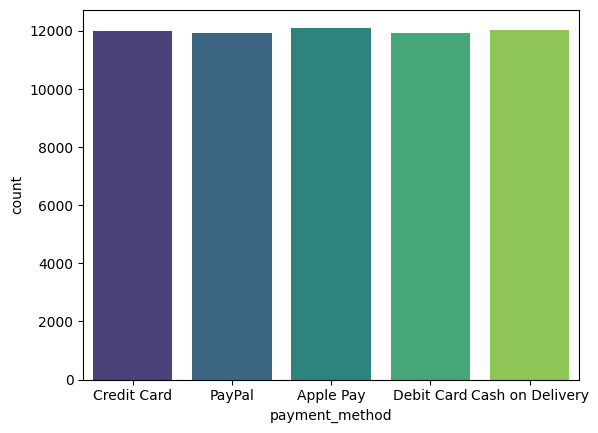

In [20]:
sns.countplot(data, x = 'payment_method', palette='viridis')

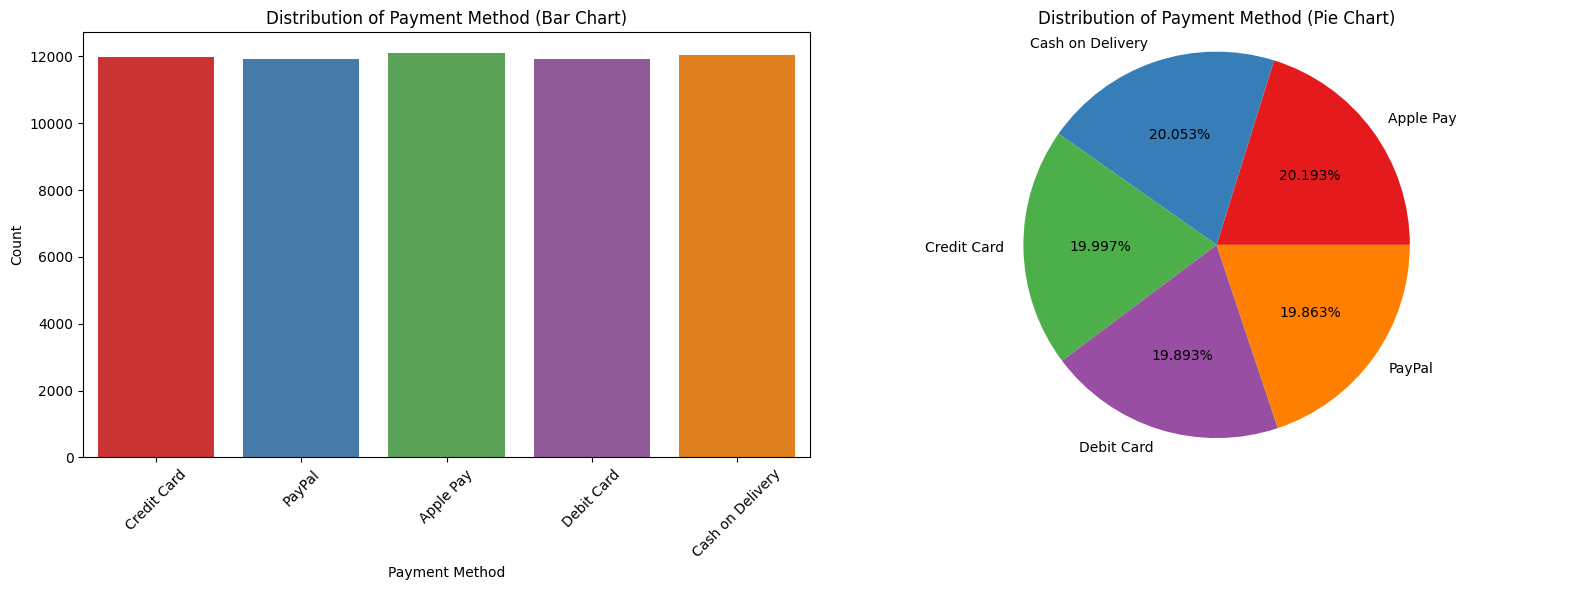

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=data, x='payment_method', palette='Set1', ax=axes[0], hue='payment_method', legend=False)
axes[0].set_title('Distribution of Payment Method (Bar Chart)')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

payment_method_counts = data['payment_method'].value_counts()
axes[1].pie(payment_method_counts, labels=payment_method_counts.index, autopct='%1.3f%%', startangle=0, colors=sns.color_palette('Set1'))
axes[1].set_title('Distribution of Payment Method (Pie Chart)')
axes[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()

## Análisis Univariante para todas las Variables Categóricas


--- Análisis para la columna: product_category ---
Número de categorías únicas: 7
Conteo de valores:


product_category
Electronics    8624
Accessories    8617
Home Decor     8600
Fashion        8594
Beauty         8586
Sports         8522
Footwear       8457
Name: count, dtype: int64


Distribución de valores (normalizada):


product_category
Electronics    0.144
Accessories    0.144
Home Decor     0.143
Fashion        0.143
Beauty         0.143
Sports         0.142
Footwear       0.141
Name: proportion, dtype: float64

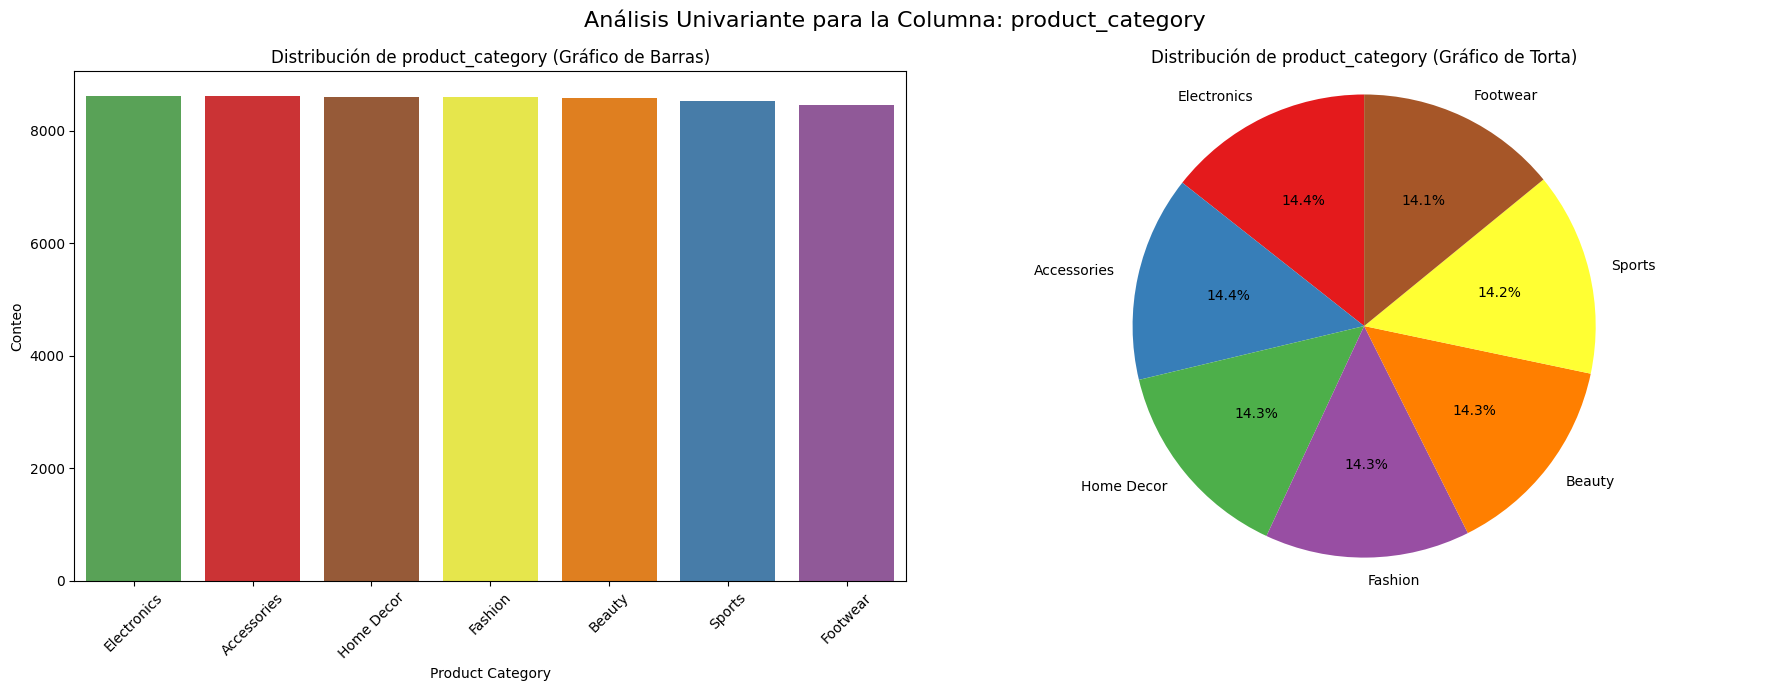


--- Análisis para la columna: customer_country ---
Número de categorías únicas: 7
Conteo de valores:


customer_country
Australia    8714
Germany      8606
UAE          8599
Canada       8586
India        8554
UK           8472
USA          8469
Name: count, dtype: int64


Distribución de valores (normalizada):


customer_country
Australia    0.145
Germany      0.143
UAE          0.143
Canada       0.143
India        0.143
UK           0.141
USA          0.141
Name: proportion, dtype: float64

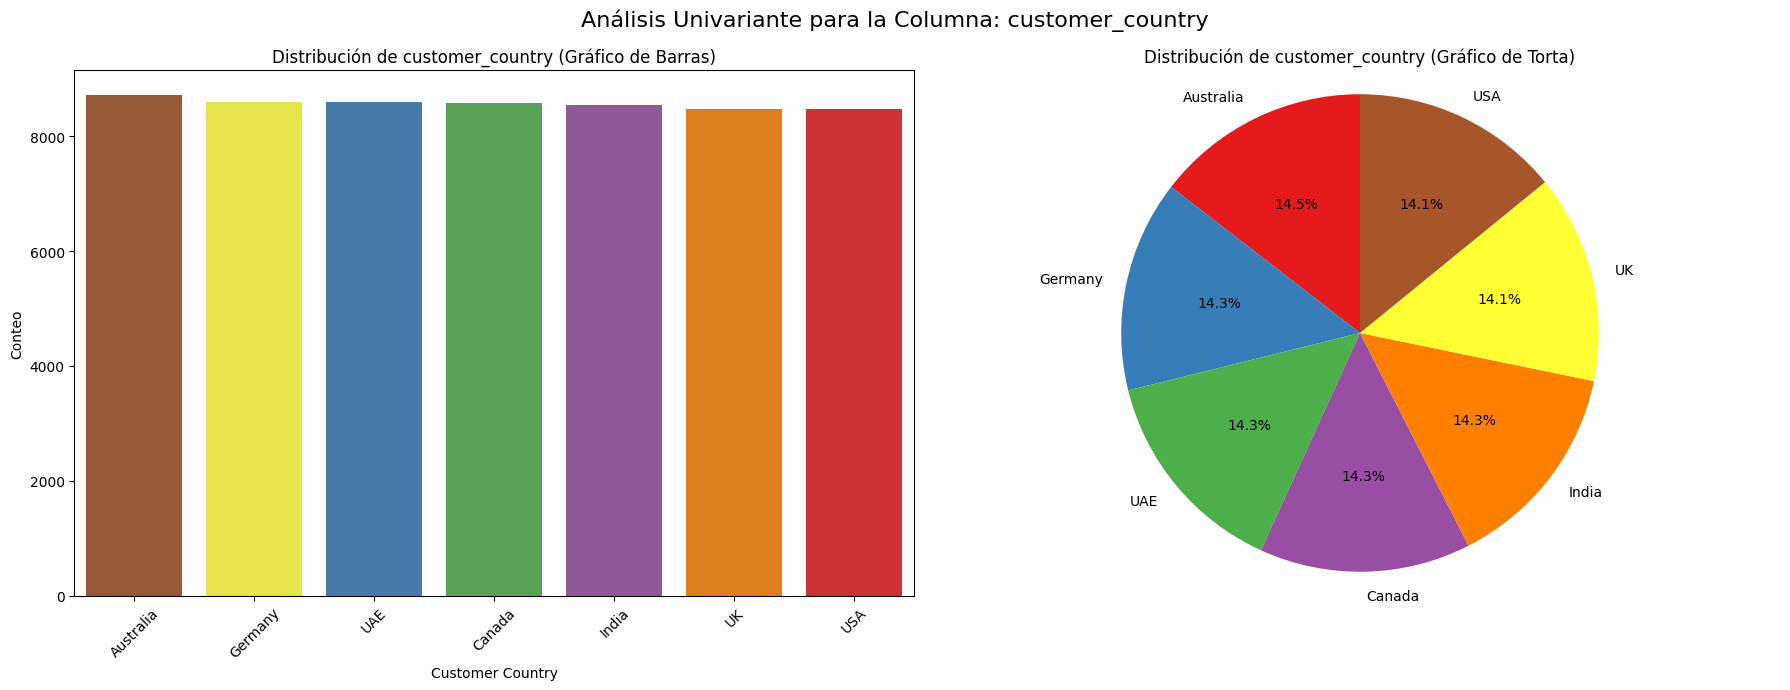


--- Análisis para la columna: traffic_source ---
Número de categorías únicas: 5
Conteo de valores:


traffic_source
Organic         12075
Social Media    12024
Paid Ads        12018
Direct          11961
Email           11922
Name: count, dtype: int64


Distribución de valores (normalizada):


traffic_source
Organic         0.201
Social Media    0.200
Paid Ads        0.200
Direct          0.199
Email           0.199
Name: proportion, dtype: float64

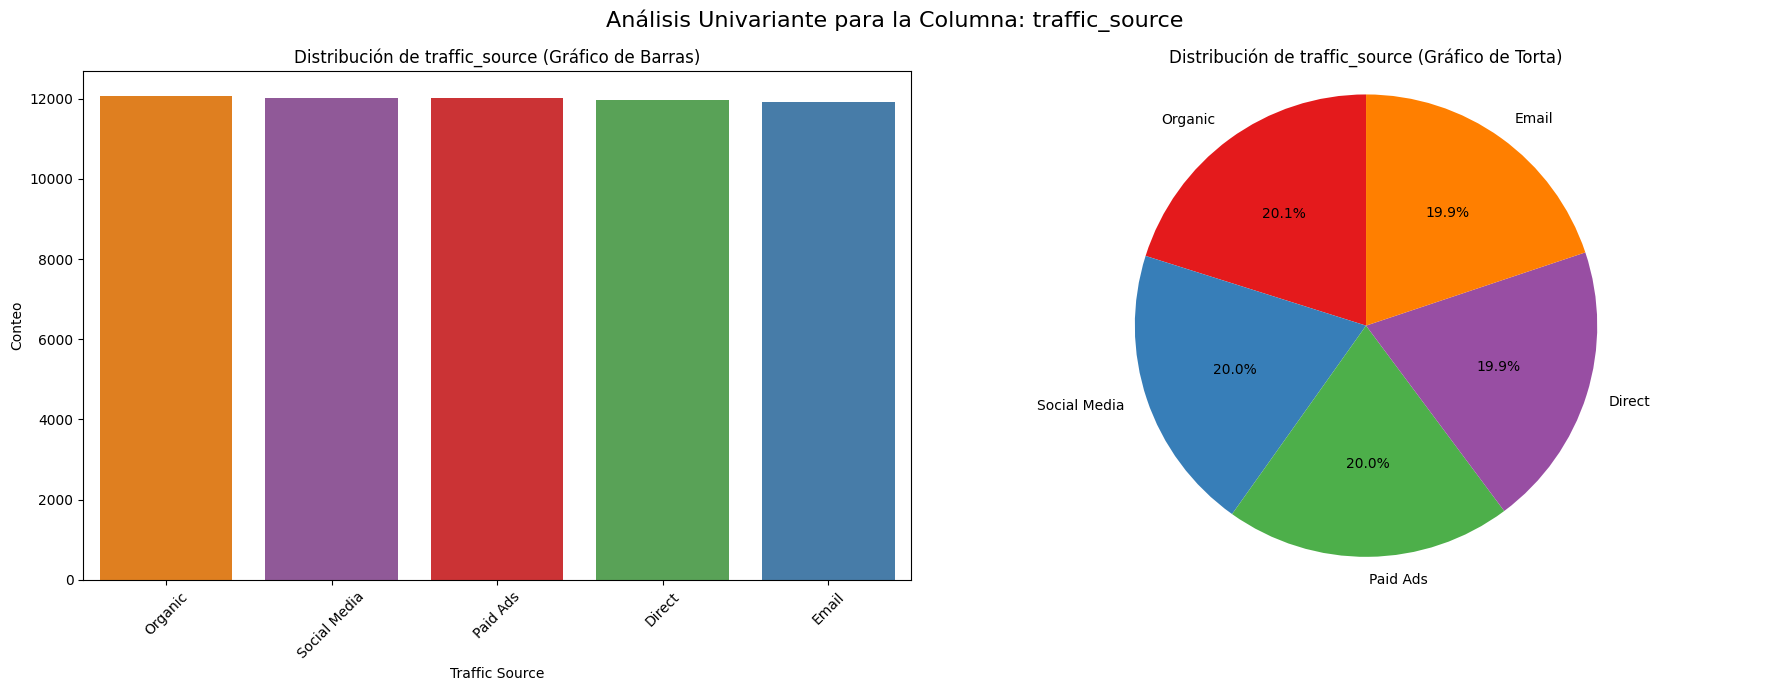


--- Análisis para la columna: payment_method ---
Número de categorías únicas: 5
Conteo de valores:


payment_method
Apple Pay           12116
Cash on Delivery    12032
Credit Card         11998
Debit Card          11936
PayPal              11918
Name: count, dtype: int64


Distribución de valores (normalizada):


payment_method
Apple Pay           0.202
Cash on Delivery    0.201
Credit Card         0.200
Debit Card          0.199
PayPal              0.199
Name: proportion, dtype: float64

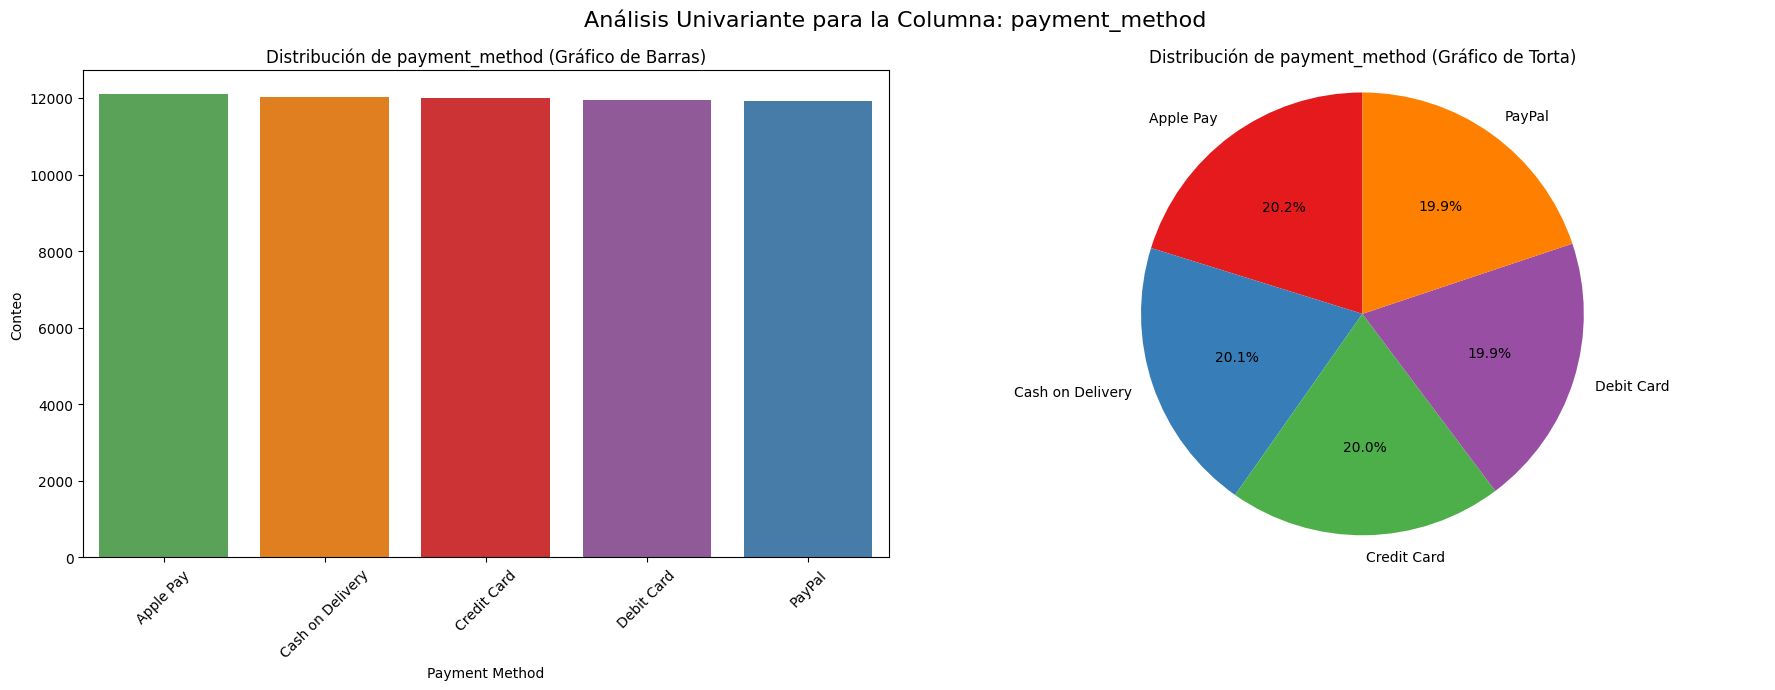


--- Análisis para la columna: product_id ---
Número de categorías únicas: 6998
Conteo de valores:


product_id
3021    20
3075    19
6072    19
3107    19
6151    19
        ..
3712     2
7702     1
5162     1
6023     1
5019     1
Name: count, Length: 6998, dtype: int64


Distribución de valores (normalizada):


product_id
3021    0.0
3075    0.0
6072    0.0
3107    0.0
6151    0.0
       ... 
3712    0.0
7702    0.0
5162    0.0
6023    0.0
5019    0.0
Name: proportion, Length: 6998, dtype: float64


--- Análisis para la columna: customer_id ---
Número de categorías únicas: 31154
Conteo de valores:


...

customer_id
21784    0.0
37140    0.0
39920    0.0
48313    0.0
19324    0.0
        ... 
31977    0.0
20572    0.0
33557    0.0
40097    0.0
41177    0.0
Name: proportion, Length: 31154, dtype: float64


--- Análisis para la columna: is_returned ---
Número de categorías únicas: 2
Conteo de valores:


is_returned
0    51113
1     8887
Name: count, dtype: int64


Distribución de valores (normalizada):


is_returned
0    0.852
1    0.148
Name: proportion, dtype: float64

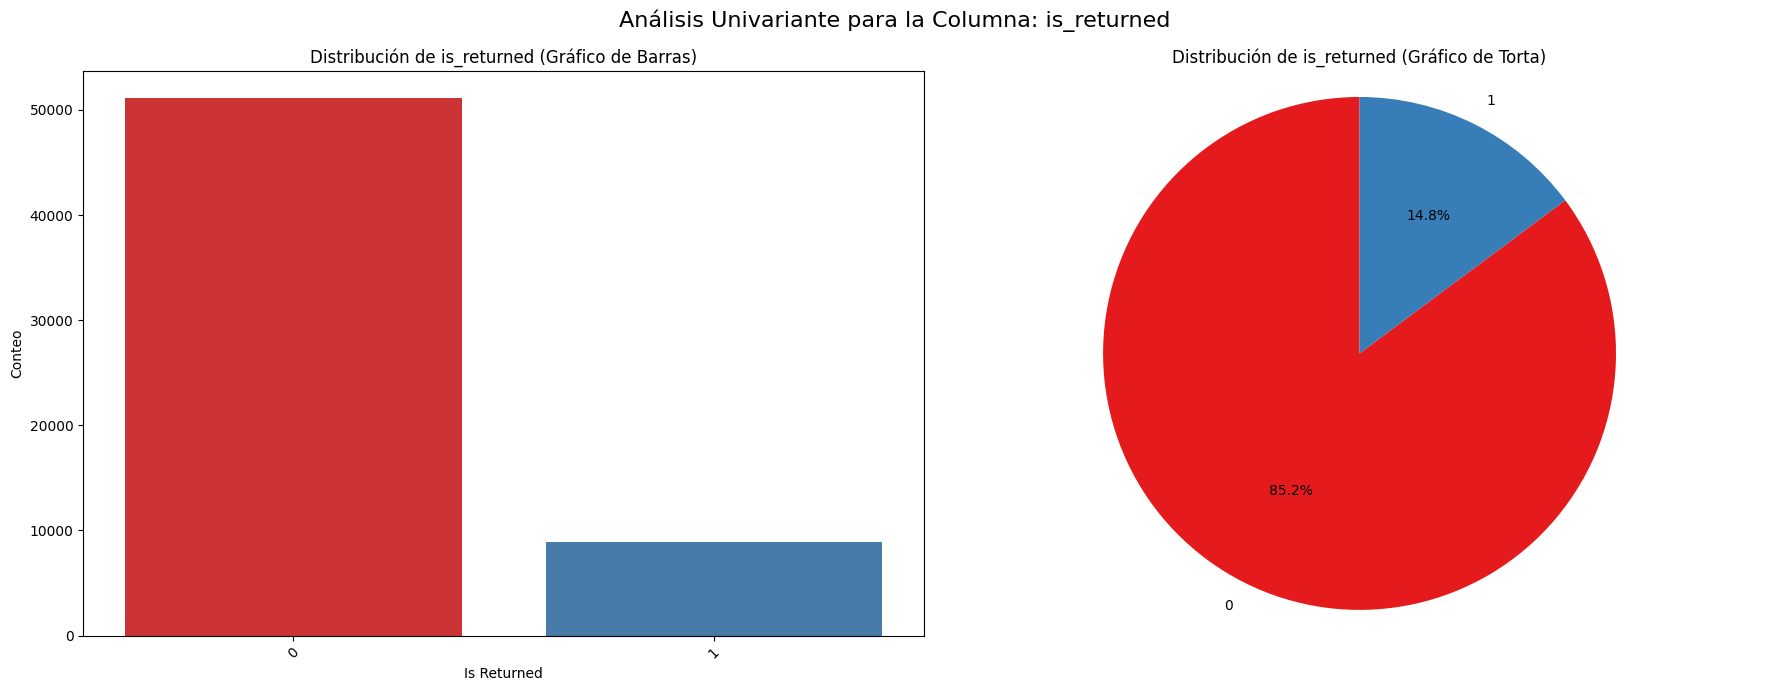

In [22]:
for col in text_columns:
    print(f"\n--- Análisis para la columna: {col} ---")
    print(f"Número de categorías únicas: {len(data[col].unique())}")

    print("Conteo de valores:")
    display(data[col].value_counts())
    print("\nDistribución de valores (normalizada):")
    display(data[col].value_counts(normalize=True).round(3))

    if col in ['product_id', 'customer_id']:
      continue
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Análisis Univariante para la Columna: {col}', fontsize=16)

    sns.countplot(data=data, x=col, palette='Set1', ax=axes[0], hue=col, legend=False, order=data[col].value_counts().index)
    axes[0].set_title(f'Distribución de {col} (Gráfico de Barras)')
    axes[0].set_xlabel(col.replace('_', ' ').title())
    axes[0].set_ylabel('Conteo')
    axes[0].tick_params(axis='x', rotation=45)

    counts = data[col].value_counts()
    axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set1'))
    axes[1].set_title(f'Distribución de {col} (Gráfico de Torta)')
    axes[1].axis('equal')

    plt.tight_layout()
    plt.show()

In [23]:
data.describe(include='object')

C:\Users\HP\AppData\Local\Temp\ipykernel_14560\3382516499.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include='object')


,product_category,customer_country,traffic_source,payment_method
count,60000,60000,60000,60000
unique,7,7,5,5
top,Electronics,Australia,Organic,Apple Pay
freq,8624,8714,12075,12116


## Análisis Univariante para todas las variables numéricas

In [24]:
data[numeric_columns].describe()

,product_price,discount_percent,quantity,shipping_cost,rating,discounted_price,revenue,profit
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,403.427068,18.151500,3.009567,13.521758,3.002440,330.220212,994.098926,980.577168
std,230.045257,12.527663,1.414794,6.627934,1.152265,197.114822,806.445785,806.508355
min,5.010000,0.000000,1.000000,2.000000,1.000000,3.080000,3.080000,-20.490000
25%,203.160000,5.000000,2.000000,7.760000,2.000000,161.957500,355.620000,341.925000
50%,403.855000,20.000000,3.000000,13.580000,3.000000,322.560000,760.470000,747.275000
75%,603.135000,30.000000,4.000000,19.230000,4.000000,482.242500,1462.450000,1449.807500
max,799.990000,40.000000,5.000000,25.000000,5.000000,799.900000,3999.500000,3989.950000


In [25]:
data[numeric_columns].mean() # mEdia de cada una de las columnas

product_price       403.427068
discount_percent     18.151500
quantity              3.009567
shipping_cost        13.521758
rating                3.002440
discounted_price    330.220212
revenue             994.098926
profit              980.577168
dtype: float64

In [26]:
data[numeric_columns].max()

product_price        799.99
discount_percent      40.00
quantity               5.00
shipping_cost         25.00
rating                 5.00
discounted_price     799.90
revenue             3999.50
profit              3989.95
dtype: float64

In [27]:
data[numeric_columns].quantile(0.25)

product_price       203.1600
discount_percent      5.0000
quantity              2.0000
shipping_cost         7.7600
rating                2.0000
discounted_price    161.9575
revenue             355.6200
profit              341.9250
Name: 0.25, dtype: float64


--- Análisis para la columna: product_price ---
Estadísticas Descriptivas:


count    60000.000000
mean       403.427068
std        230.045257
min          5.010000
25%        203.160000
50%        403.855000
75%        603.135000
max        799.990000
Name: product_price, dtype: float64

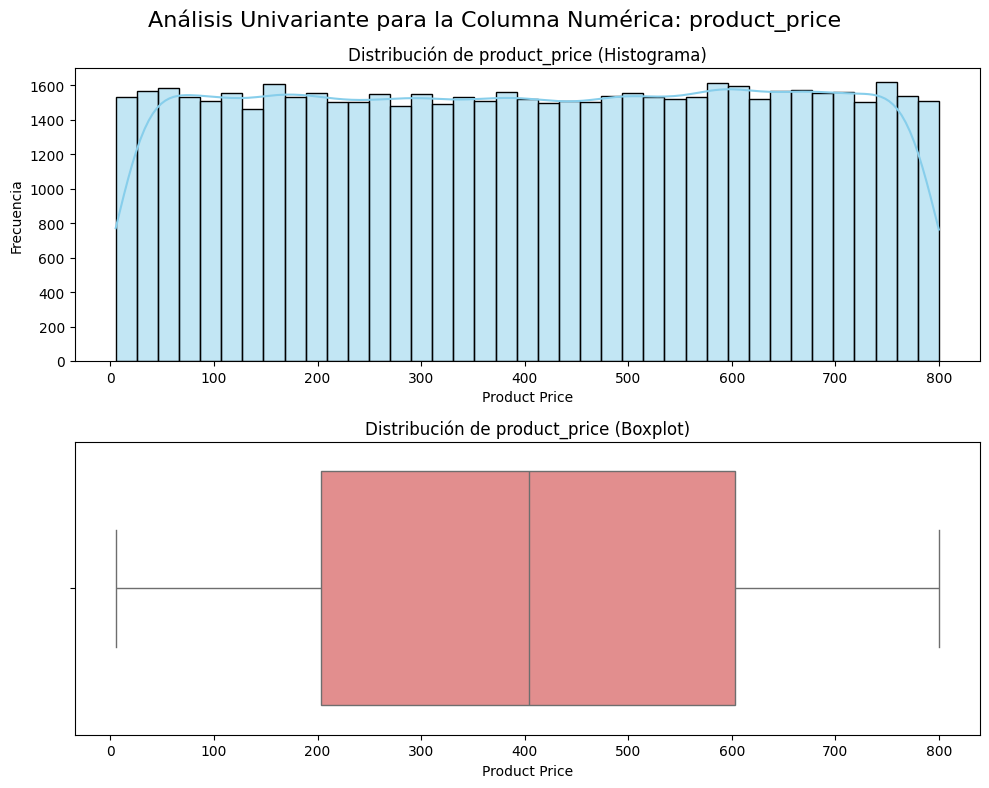


--- Análisis para la columna: discount_percent ---
Estadísticas Descriptivas:


count    60000.000000
mean        18.151500
std         12.527663
min          0.000000
25%          5.000000
50%         20.000000
75%         30.000000
max         40.000000
Name: discount_percent, dtype: float64

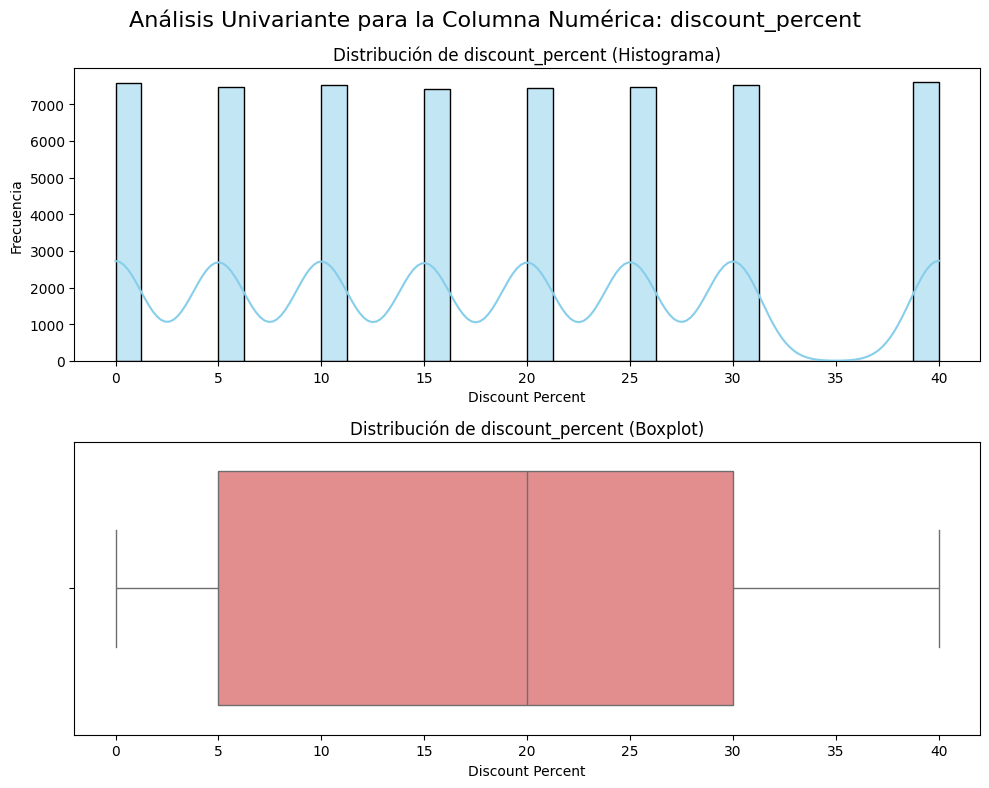


--- Análisis para la columna: quantity ---
Estadísticas Descriptivas:


count    60000.000000
mean         3.009567
std          1.414794
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: quantity, dtype: float64

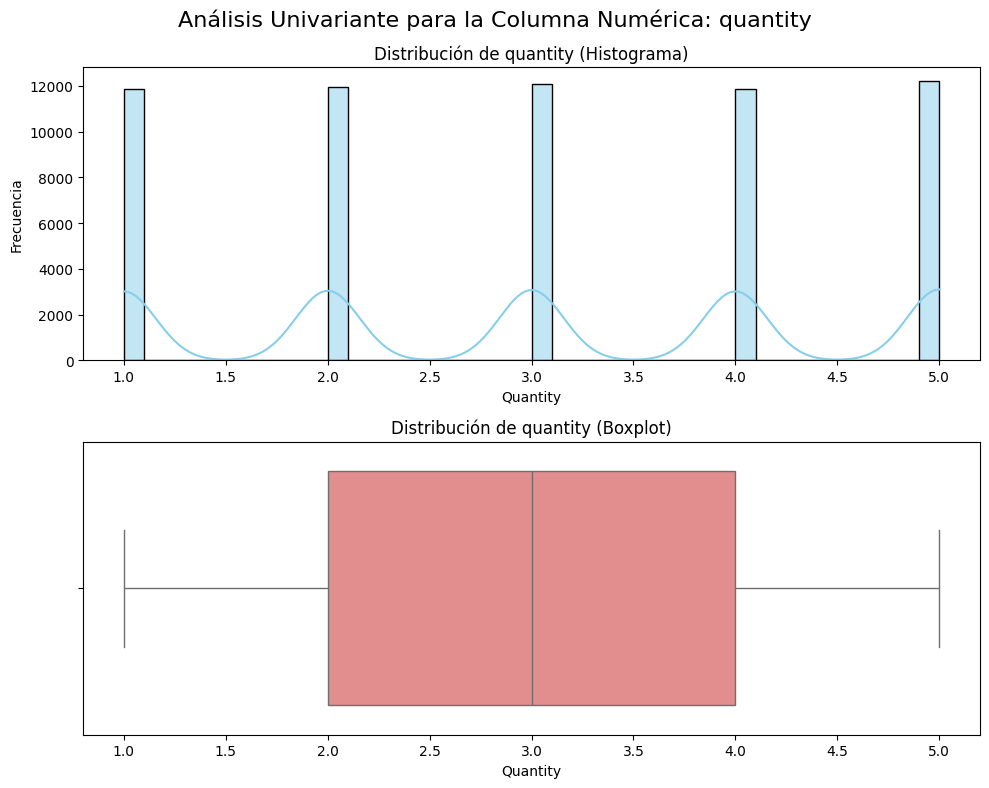


--- Análisis para la columna: shipping_cost ---
Estadísticas Descriptivas:


count    60000.000000
mean        13.521758
std          6.627934
min          2.000000
25%          7.760000
50%         13.580000
75%         19.230000
max         25.000000
Name: shipping_cost, dtype: float64

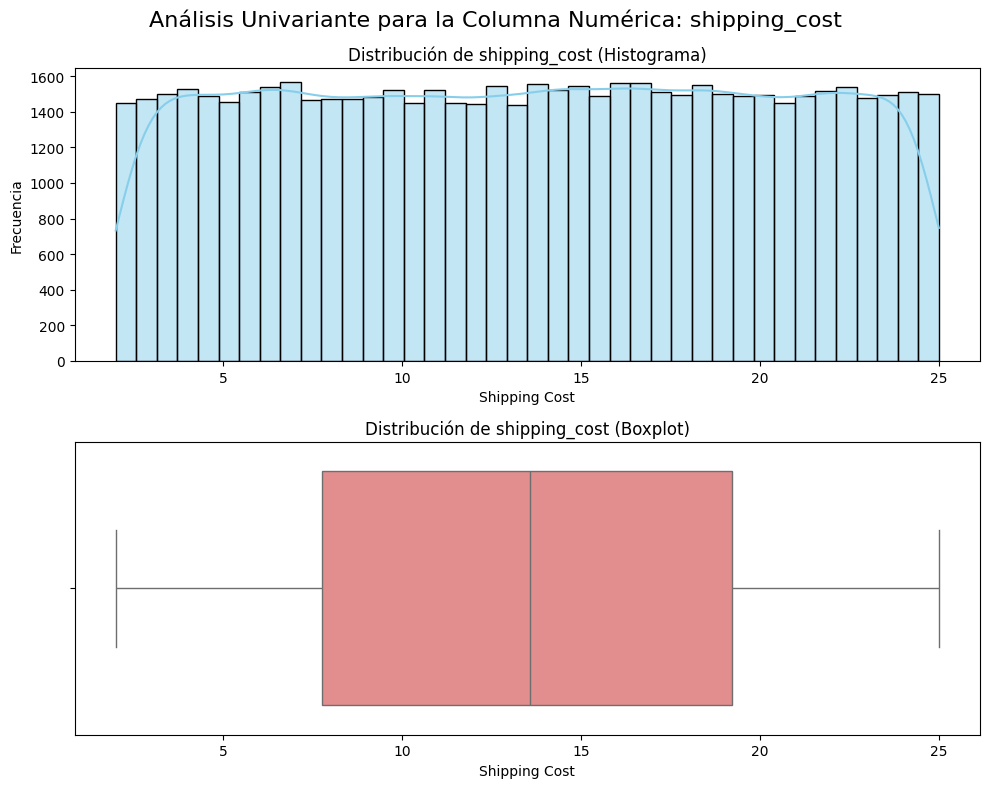


--- Análisis para la columna: rating ---
Estadísticas Descriptivas:


count    60000.000000
mean         3.002440
std          1.152265
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: rating, dtype: float64

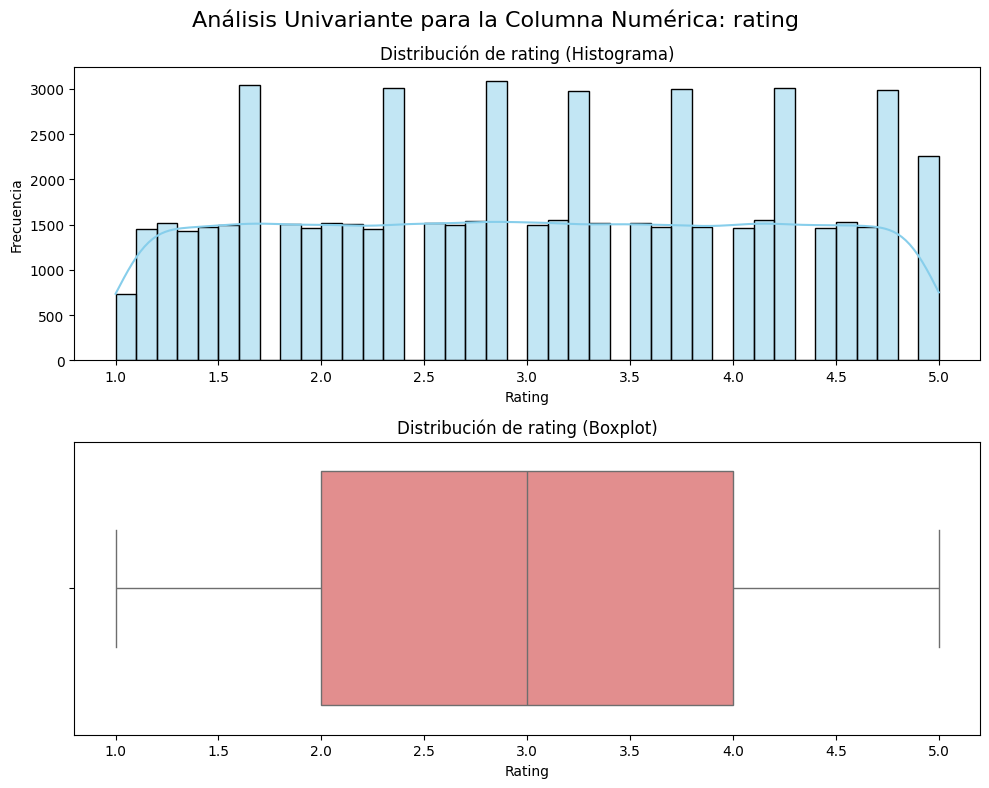


--- Análisis para la columna: discounted_price ---
Estadísticas Descriptivas:


count    60000.000000
mean       330.220212
std        197.114822
min          3.080000
25%        161.957500
50%        322.560000
75%        482.242500
max        799.900000
Name: discounted_price, dtype: float64

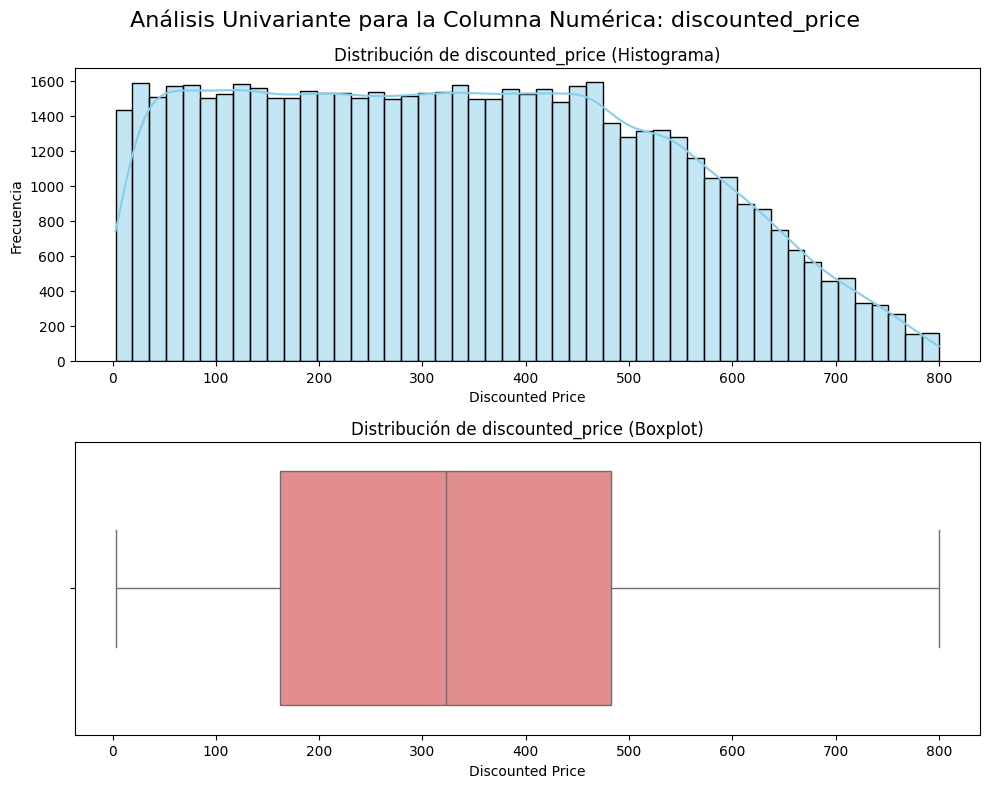


--- Análisis para la columna: revenue ---
Estadísticas Descriptivas:


count    60000.000000
mean       994.098926
std        806.445785
min          3.080000
25%        355.620000
50%        760.470000
75%       1462.450000
max       3999.500000
Name: revenue, dtype: float64

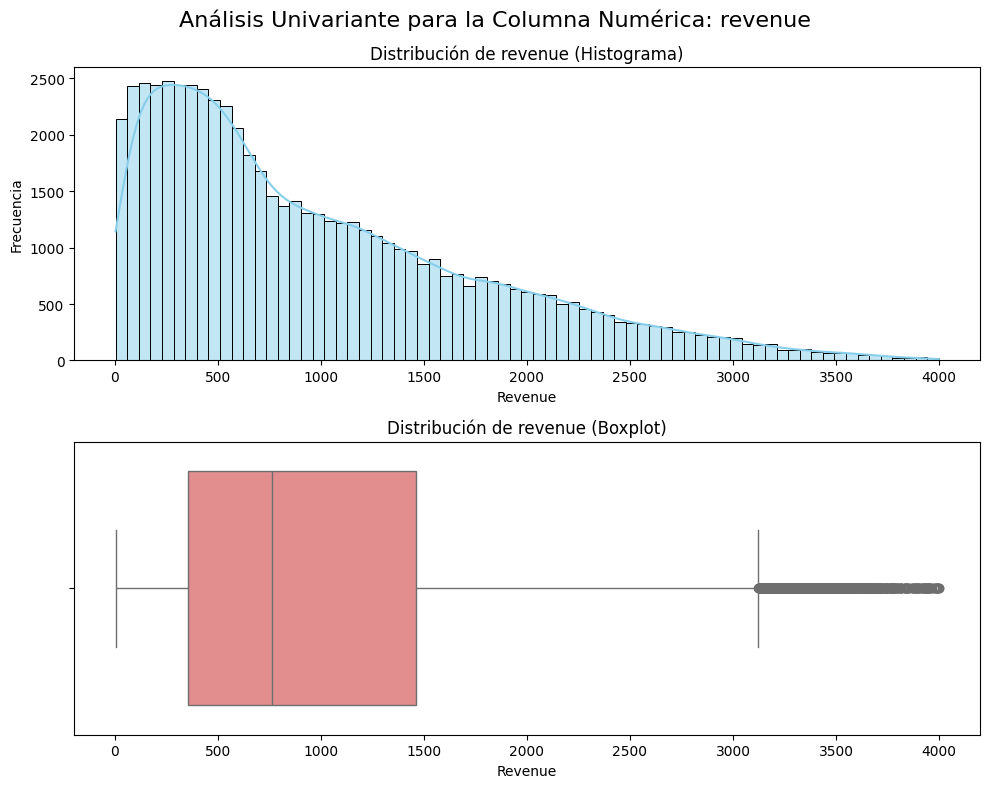


--- Análisis para la columna: profit ---
Estadísticas Descriptivas:


count    60000.000000
mean       980.577168
std        806.508355
min        -20.490000
25%        341.925000
50%        747.275000
75%       1449.807500
max       3989.950000
Name: profit, dtype: float64

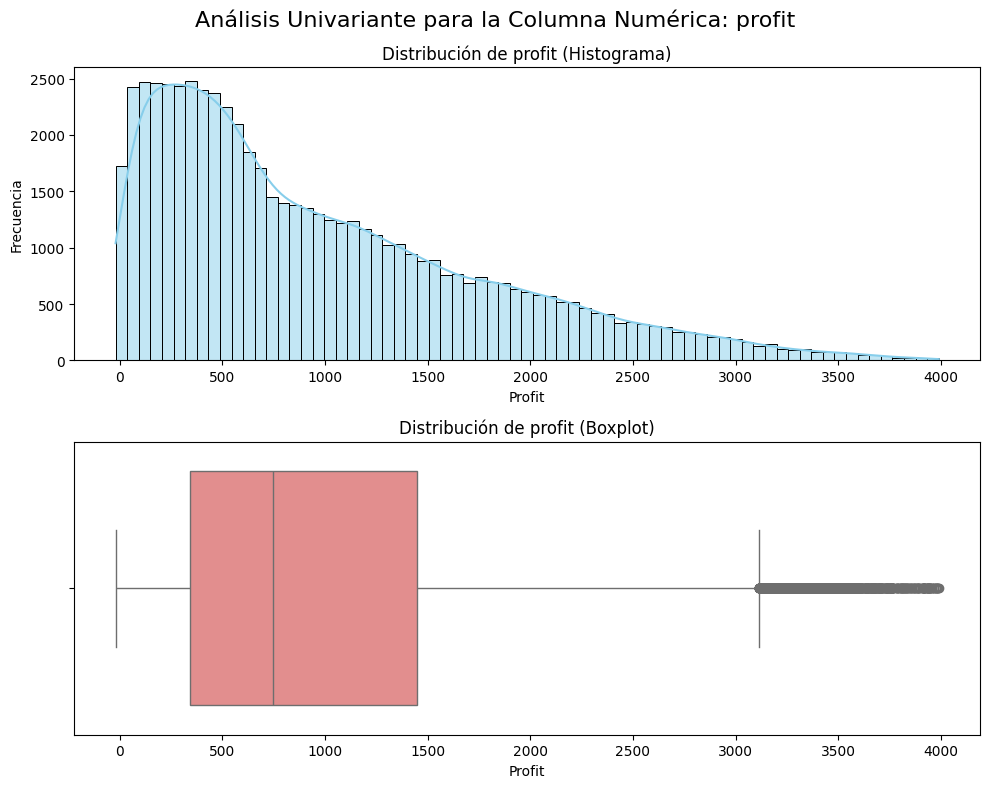

In [28]:
for col in numeric_columns:
    print(f"\n--- Análisis para la columna: {col} ---")
    print("Estadísticas Descriptivas:")
    display(data[col].describe())

    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    fig.suptitle(f'Análisis Univariante para la Columna Numérica: {col}', fontsize=16)

    sns.histplot(data=data, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribución de {col} (Histograma)')
    axes[0].set_xlabel(col.replace('_', ' ').title())
    axes[0].set_ylabel('Frecuencia')

    sns.boxplot(data=data, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Distribución de {col} (Boxplot)')
    axes[1].set_xlabel(col.replace('_', ' ').title())

    plt.tight_layout()
    plt.show()

## Análisis Univariante para variables temporales (variables de tiempo)

Fecha mínima: 2023-01-01 00:00:00
Fecha máxima: 2025-06-18 00:00:00
Fecha más frecuente: 2024-10-18 00:00:00


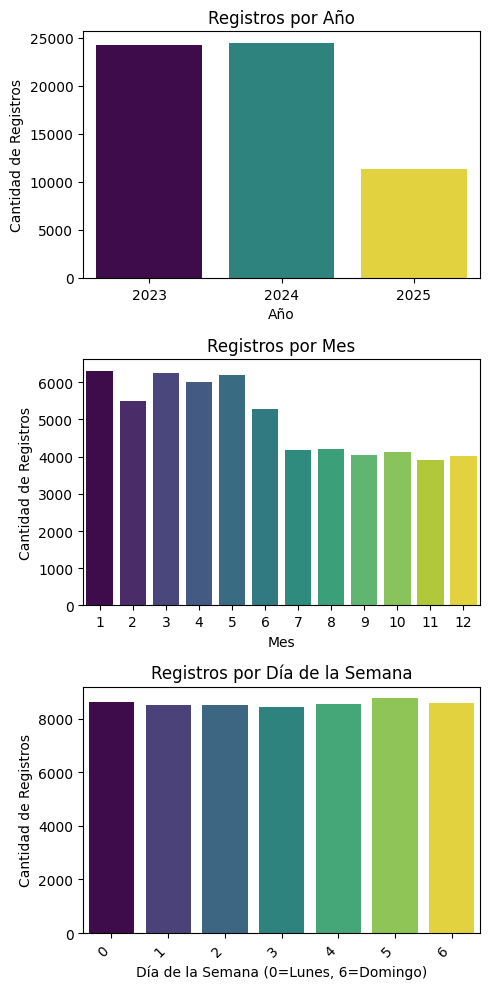

In [29]:
print('Fecha mínima:', data['order_date'].min())
print('Fecha máxima:', data['order_date'].max())
print('Fecha más frecuente:', data['order_date'].mode()[0])

# Extract date components
data['order_year'] = data['order_date'].dt.year
data['order_month'] = data['order_date'].dt.month
data['order_day_of_week'] = data['order_date'].dt.dayofweek # 0=Monday, 6=Sunday

plt.figure(figsize=(5, 10))

plt.subplot(3, 1, 1)
sns.countplot(x='order_year', data=data, palette='viridis', hue='order_year', legend=False)
plt.title('Registros por Año')
plt.xlabel('Año')
plt.ylabel('Cantidad de Registros')

plt.subplot(3, 1, 2)
sns.countplot(x='order_month', data=data, palette='viridis', hue='order_month', legend=False)
plt.title('Registros por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Registros')

plt.subplot(3, 1, 3)
sns.countplot(x='order_day_of_week', data=data, palette='viridis', hue='order_day_of_week', legend=False)
plt.title('Registros por Día de la Semana')
plt.xlabel('Día de la Semana (0=Lunes, 6=Domingo)')
plt.ylabel('Cantidad de Registros')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Drop the temporary columns to keep the DataFrame clean if not needed further
data.drop(columns=['order_year', 'order_month', 'order_day_of_week'], inplace=True)
 

# Análisis bivariante

## Numérico

In [30]:
data[numeric_columns].corr()

,product_price,discount_percent,quantity,shipping_cost,rating,discounted_price,revenue,profit
product_price,1.000000,-0.000737,0.000847,-0.005456,-0.001774,0.955715,0.706162,0.706152
discount_percent,-0.000737,1.000000,-0.000939,-0.003466,-0.004019,-0.255998,-0.188741,-0.188698
quantity,0.000847,-0.000939,1.000000,-0.002925,0.003388,0.001001,0.579274,0.579254
shipping_cost,-0.005456,-0.003466,-0.002925,1.000000,-0.001226,-0.004050,-0.005331,-0.013549
rating,-0.001774,-0.004019,0.003388,-0.001226,1.000000,-0.001003,-0.000355,-0.000345
discounted_price,0.955715,-0.255998,0.001001,-0.004050,-0.001003,1.000000,0.739114,0.739090
revenue,0.706162,-0.188741,0.579274,-0.005331,-0.000355,0.739114,1.000000,0.999966
profit,0.706152,-0.188698,0.579254,-0.013549,-0.000345,0.739090,0.999966,1.000000


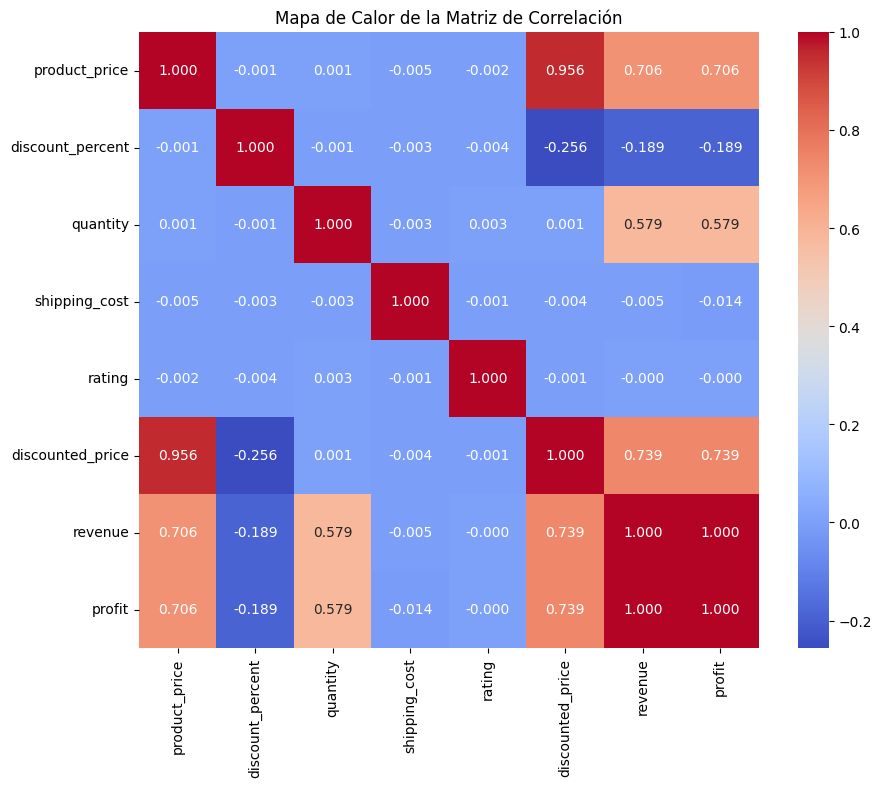

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(data[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt=".3f")
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()

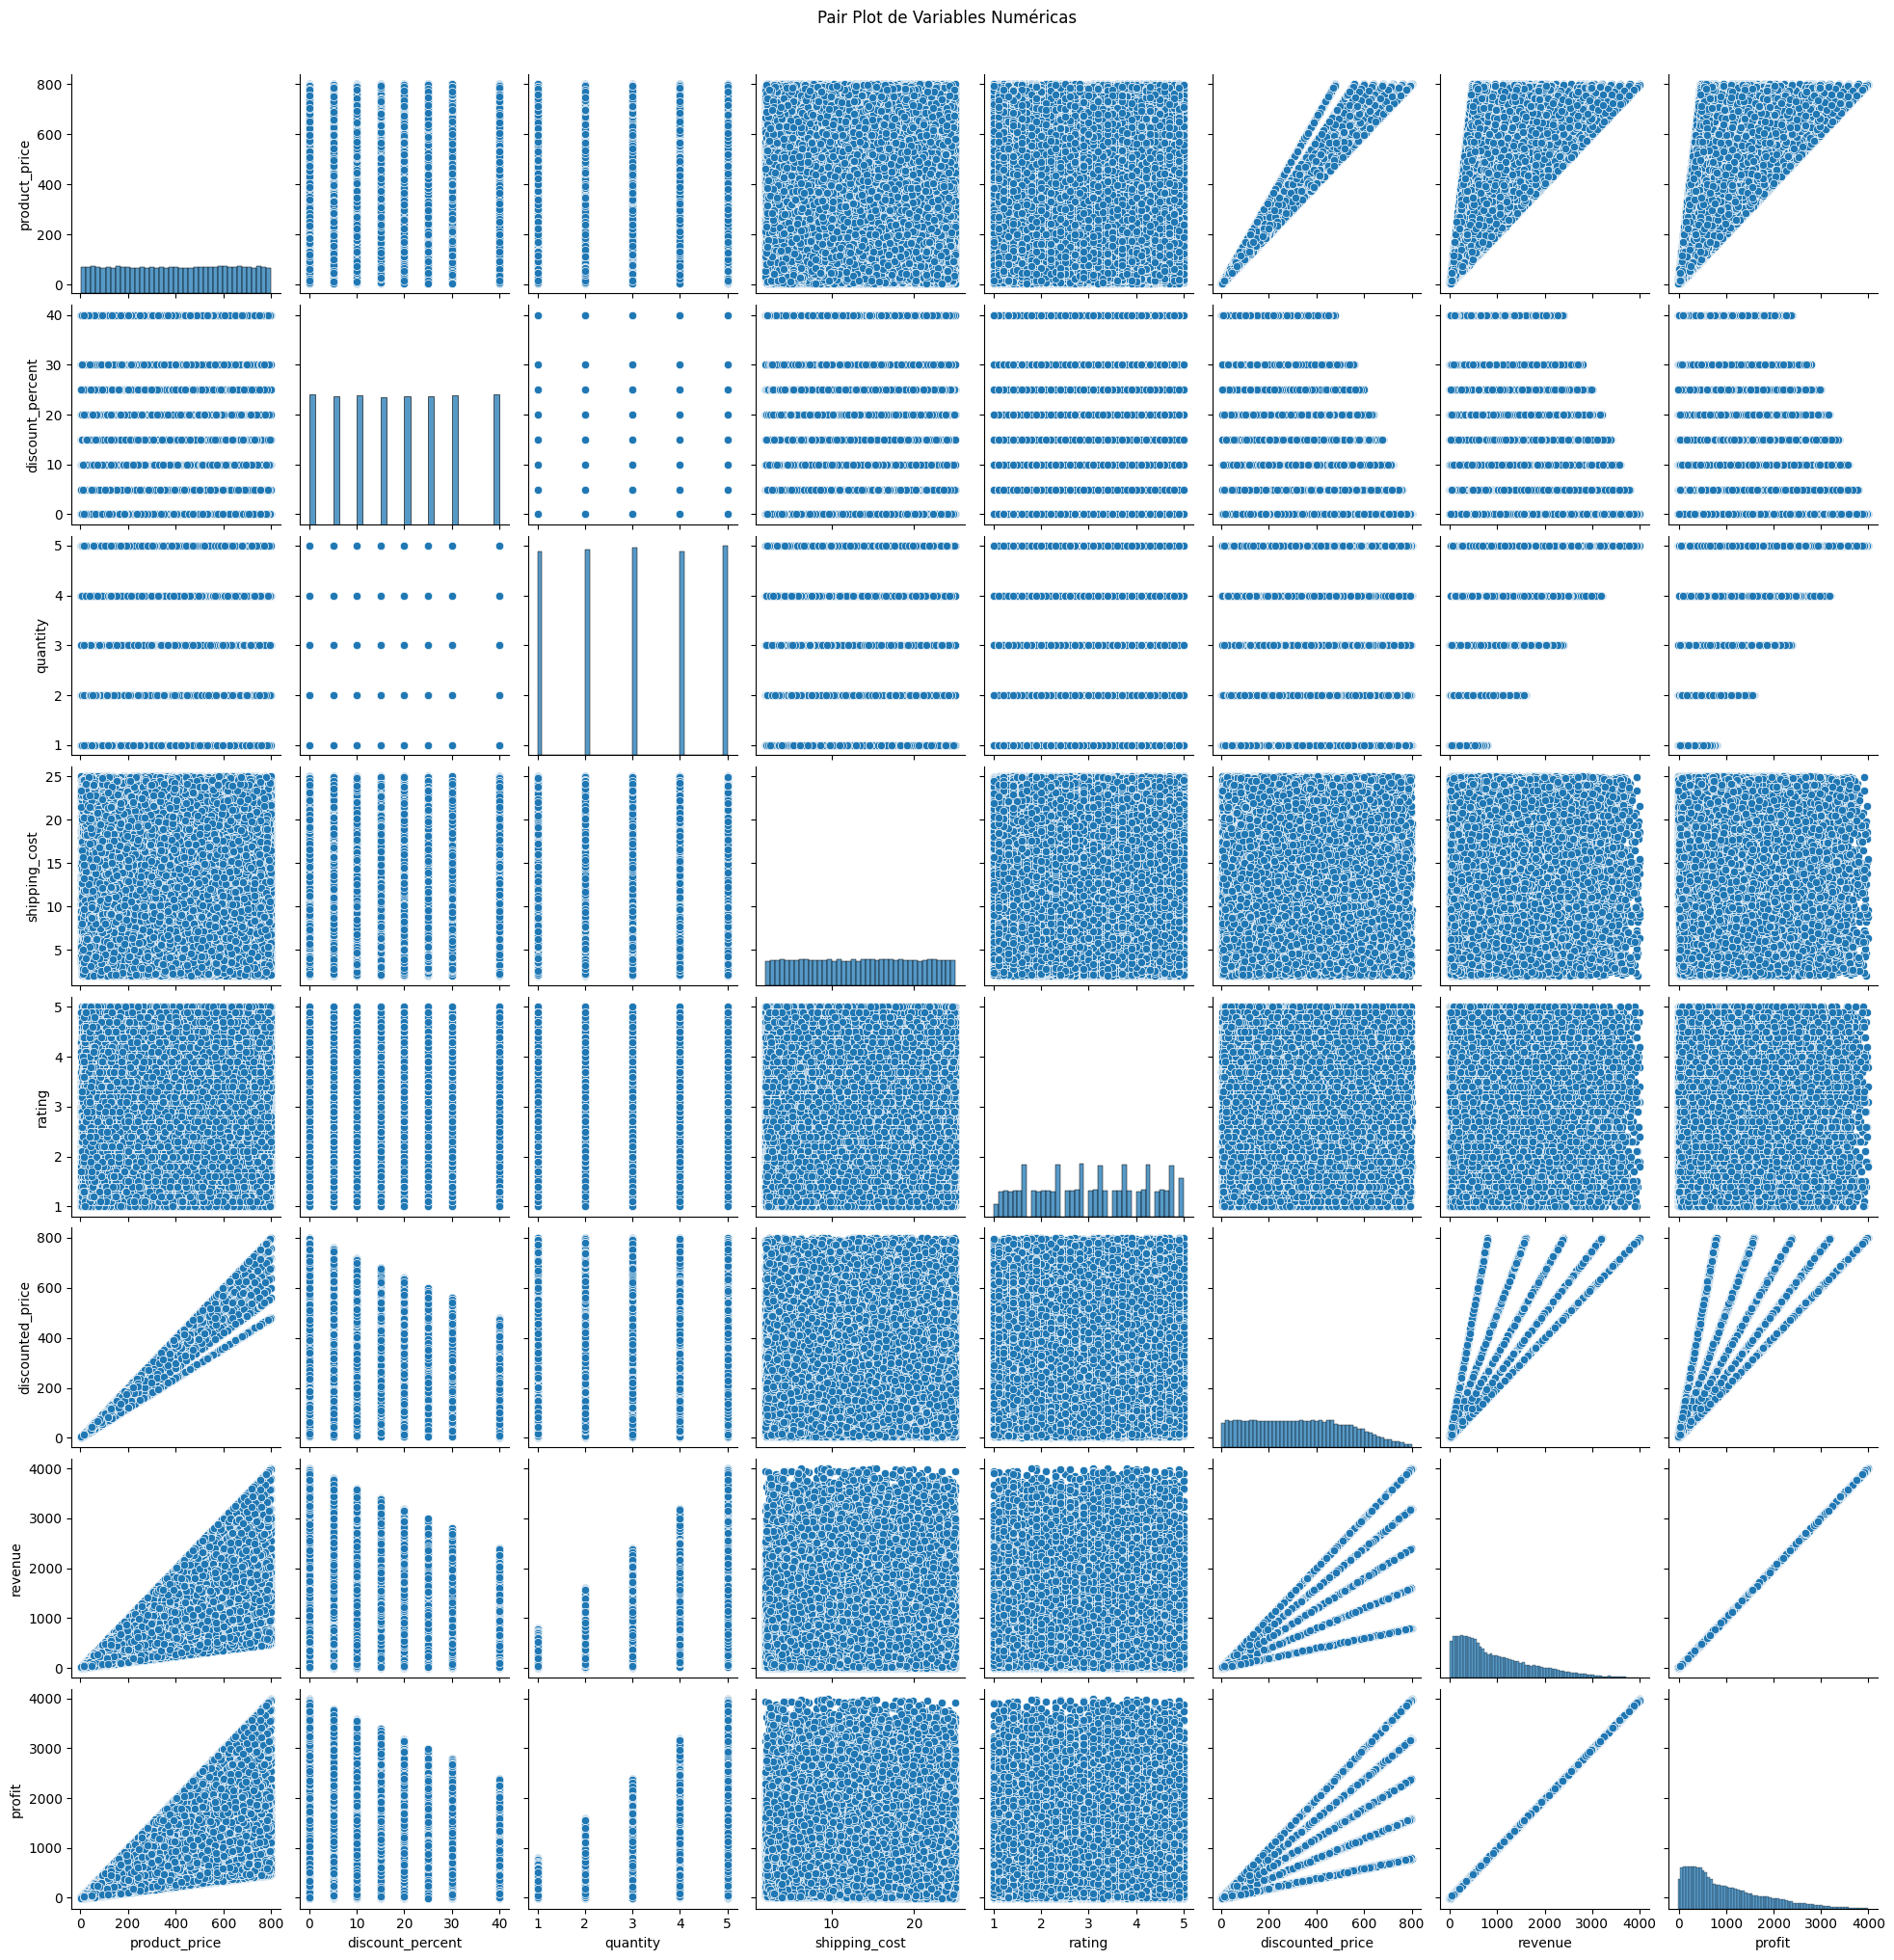

In [32]:
sns.pairplot(data[numeric_columns])
plt.suptitle('Pair Plot de Variables Numéricas', y=1.02)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


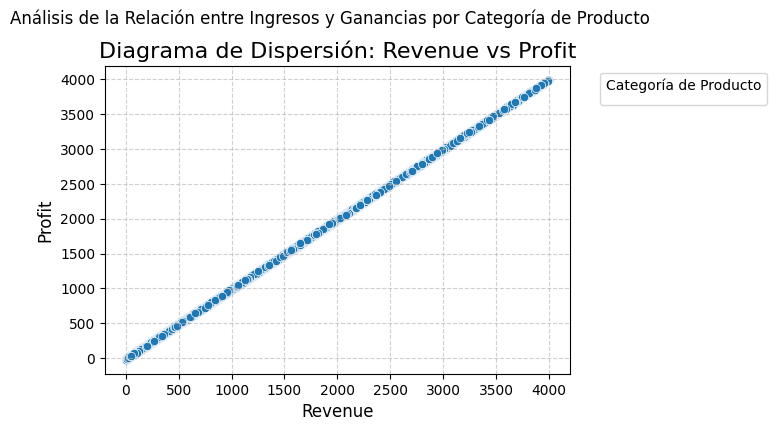

In [39]:
columna_x = 'revenue'
columna_y = 'profit'

plt.figure(figsize=(6, 4))
sns.scatterplot(data=data, x=columna_x, y=columna_y)

plt.title(f'Diagrama de Dispersión: {columna_x.replace("_", " ").title()} vs {columna_y.replace("_", " ").title()}', fontsize=16)
plt.suptitle('Análisis de la Relación entre Ingresos y Ganancias por Categoría de Producto', fontsize=12, y=1.02)
plt.xlabel(columna_x.replace('_', ' ').title(), fontsize=12)
plt.ylabel(columna_y.replace('_', ' ').title(), fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Categoría de Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Categóricas

In [40]:
columna_cat_1 = 'product_category'
columna_cat_2 = 'customer_country'

crosstab_result = pd.crosstab(data[columna_cat_1], data[columna_cat_2])

print(f"Tabla de contingencia entre '{columna_cat_1}' y '{columna_cat_2}':")
display(crosstab_result)

print(f"\nTabla de contingencia normalizada entre '{columna_cat_1}' y '{columna_cat_2}':")
display(pd.crosstab(data[columna_cat_1], data[columna_cat_2], normalize=True).round(3))

Tabla de contingencia entre 'product_category' y 'customer_country':


customer_country,Australia,Canada,Germany,India,UAE,UK,USA
product_category,,,,,,,
Accessories,1209,1195,1277,1208,1230,1277,1221
Beauty,1274,1274,1230,1206,1265,1149,1188
Electronics,1200,1208,1256,1206,1273,1224,1257
Fashion,1251,1280,1214,1206,1213,1191,1239
Footwear,1255,1243,1151,1235,1214,1196,1163
Home Decor,1232,1229,1232,1235,1219,1238,1215
Sports,1293,1157,1246,1258,1185,1197,1186



Tabla de contingencia normalizada entre 'product_category' y 'customer_country':


customer_country,Australia,Canada,Germany,India,UAE,UK,USA
product_category,,,,,,,
Accessories,0.020,0.020,0.021,0.020,0.020,0.021,0.020
Beauty,0.021,0.021,0.020,0.020,0.021,0.019,0.020
Electronics,0.020,0.020,0.021,0.020,0.021,0.020,0.021
Fashion,0.021,0.021,0.020,0.020,0.020,0.020,0.021
Footwear,0.021,0.021,0.019,0.021,0.020,0.020,0.019
Home Decor,0.021,0.020,0.021,0.021,0.020,0.021,0.020
Sports,0.022,0.019,0.021,0.021,0.020,0.020,0.020


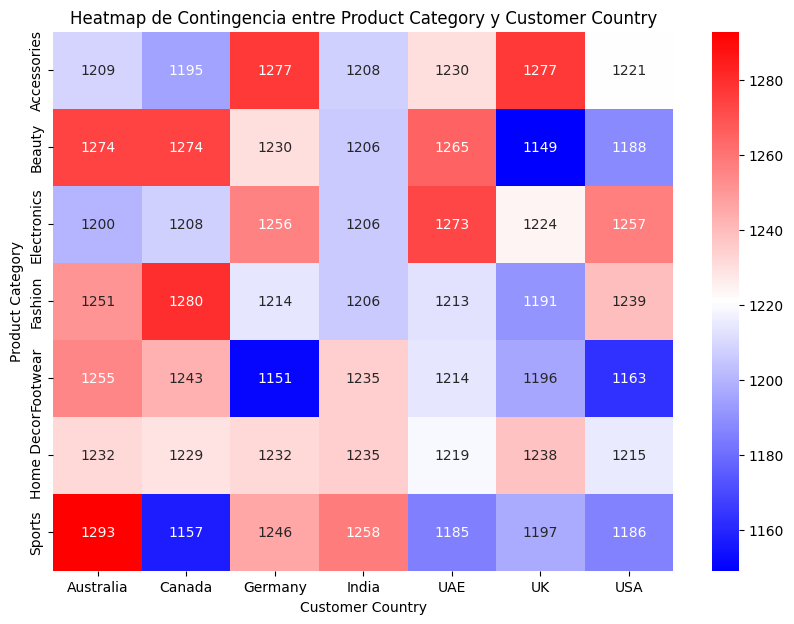

In [43]:
plt.figure(figsize=(10, 7))
sns.heatmap(crosstab_result, annot=True, fmt='d', cmap='bwr')
plt.title(f'Heatmap de Contingencia entre {columna_cat_1.replace("_", " ").title()} y {columna_cat_2.replace("_", " ").title()}')
plt.xlabel(columna_cat_2.replace('_', ' ').title())
plt.ylabel(columna_cat_1.replace('_', ' ').title())
plt.show()

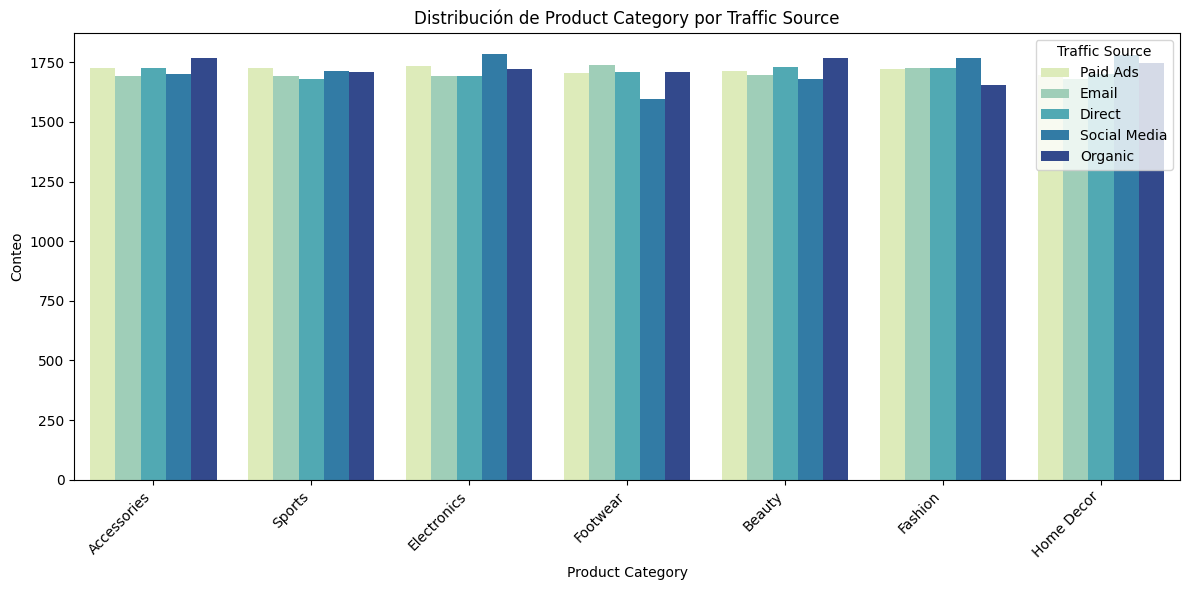

In [44]:
columna_cat_1 = 'product_category'
columna_cat_2 = 'traffic_source'

plt.figure(figsize=(12, 6))
sns.countplot(data=data, x=columna_cat_1, hue=columna_cat_2, palette='YlGnBu')
plt.title(f'Distribución de {columna_cat_1.replace("_", " ").title()} por {columna_cat_2.replace("_", " ").title()}')
plt.xlabel(columna_cat_1.replace('_', ' ').title())
plt.ylabel('Conteo')
plt.xticks(rotation=45, ha='right')
plt.legend(title=columna_cat_2.replace('_', ' ').title())
plt.tight_layout()
plt.show()

## Categórico + Numérico

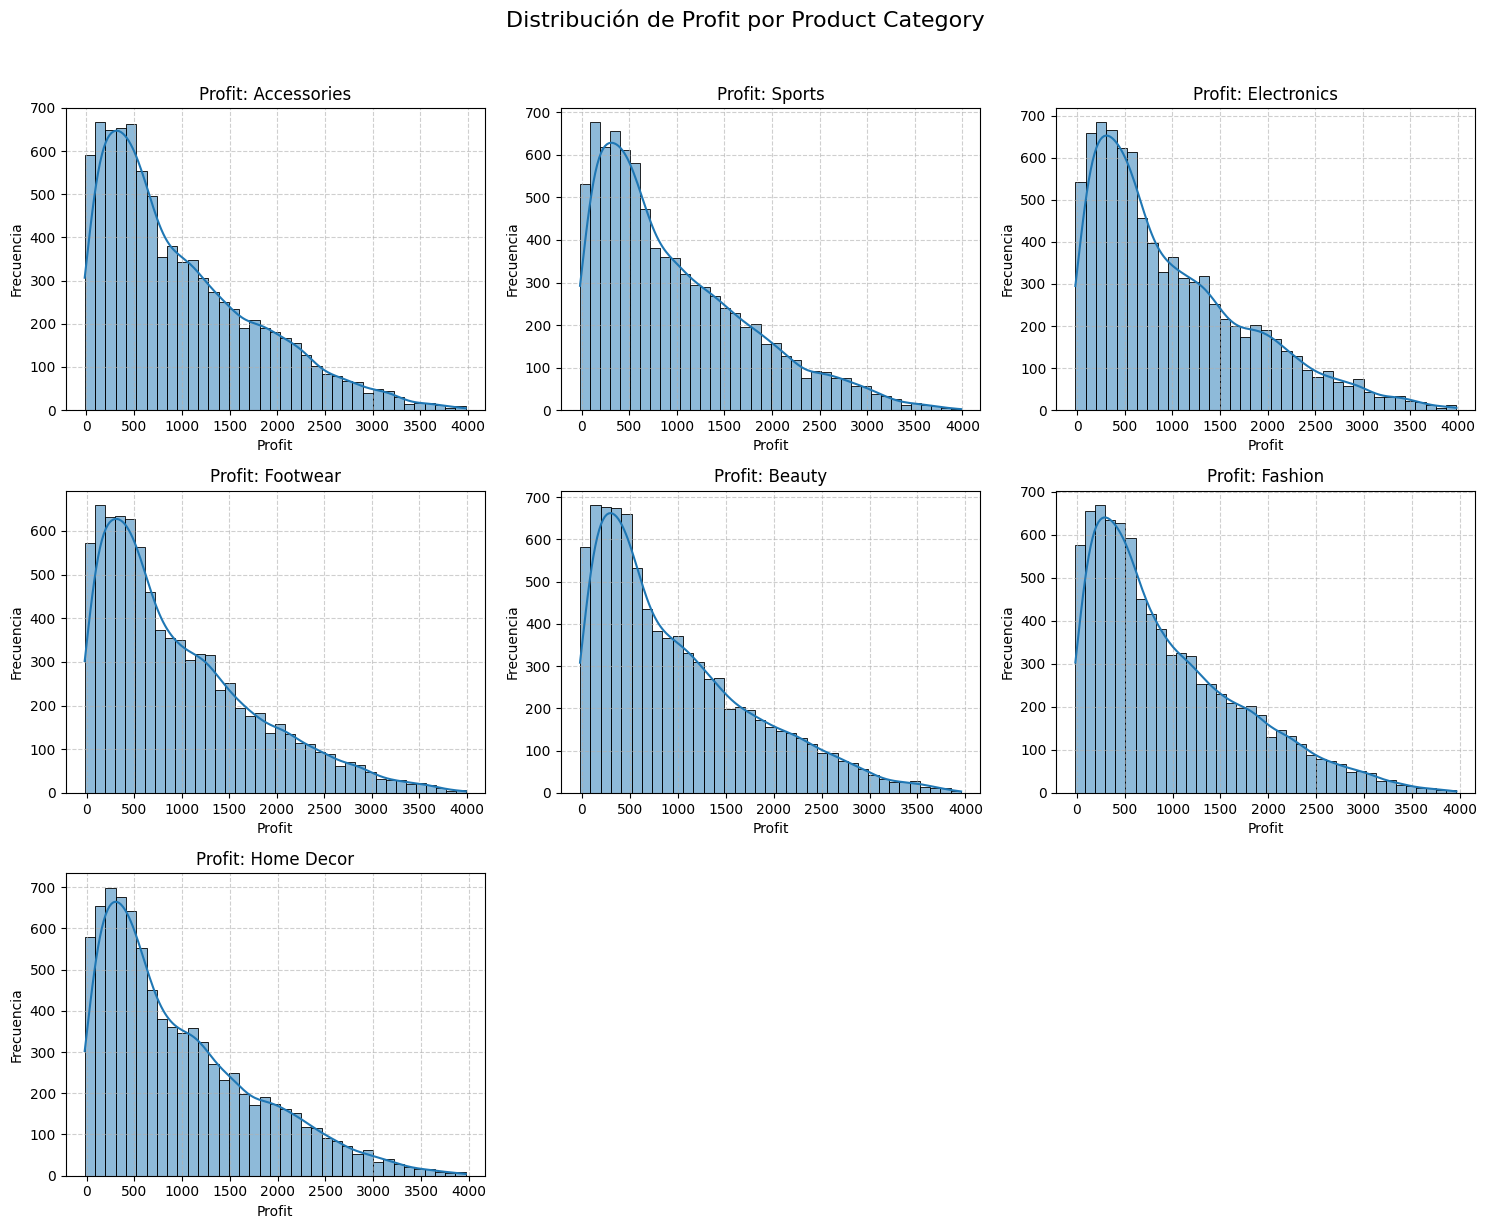

In [ ]:
columna_categorica = 'product_category'
columna_numerica = 'profit'

unique_categories = data[columna_categorica].unique()
num_categories = len(unique_categories)

# Determine grid size for subplots
num_cols = 3 # You can adjust this number
num_rows = (num_categories + num_cols - 1) // num_cols
# ( 7 + 3 - 1 ) // 3  = 9 // 3 = 3

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, category in enumerate(unique_categories):
    subset_data = data[data[columna_categorica] == category]
    sns.histplot(data=subset_data, x=columna_numerica, kde=True, ax=axes[i]) # Removed palette argument
    axes[i].set_title(f'Profit: {category}')
    axes[i].set_xlabel('Profit')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(True, linestyle='--', alpha=0.6)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Distribución de {columna_numerica.replace("_", " ").title()} por {columna_categorica.replace("_", " ").title()}', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

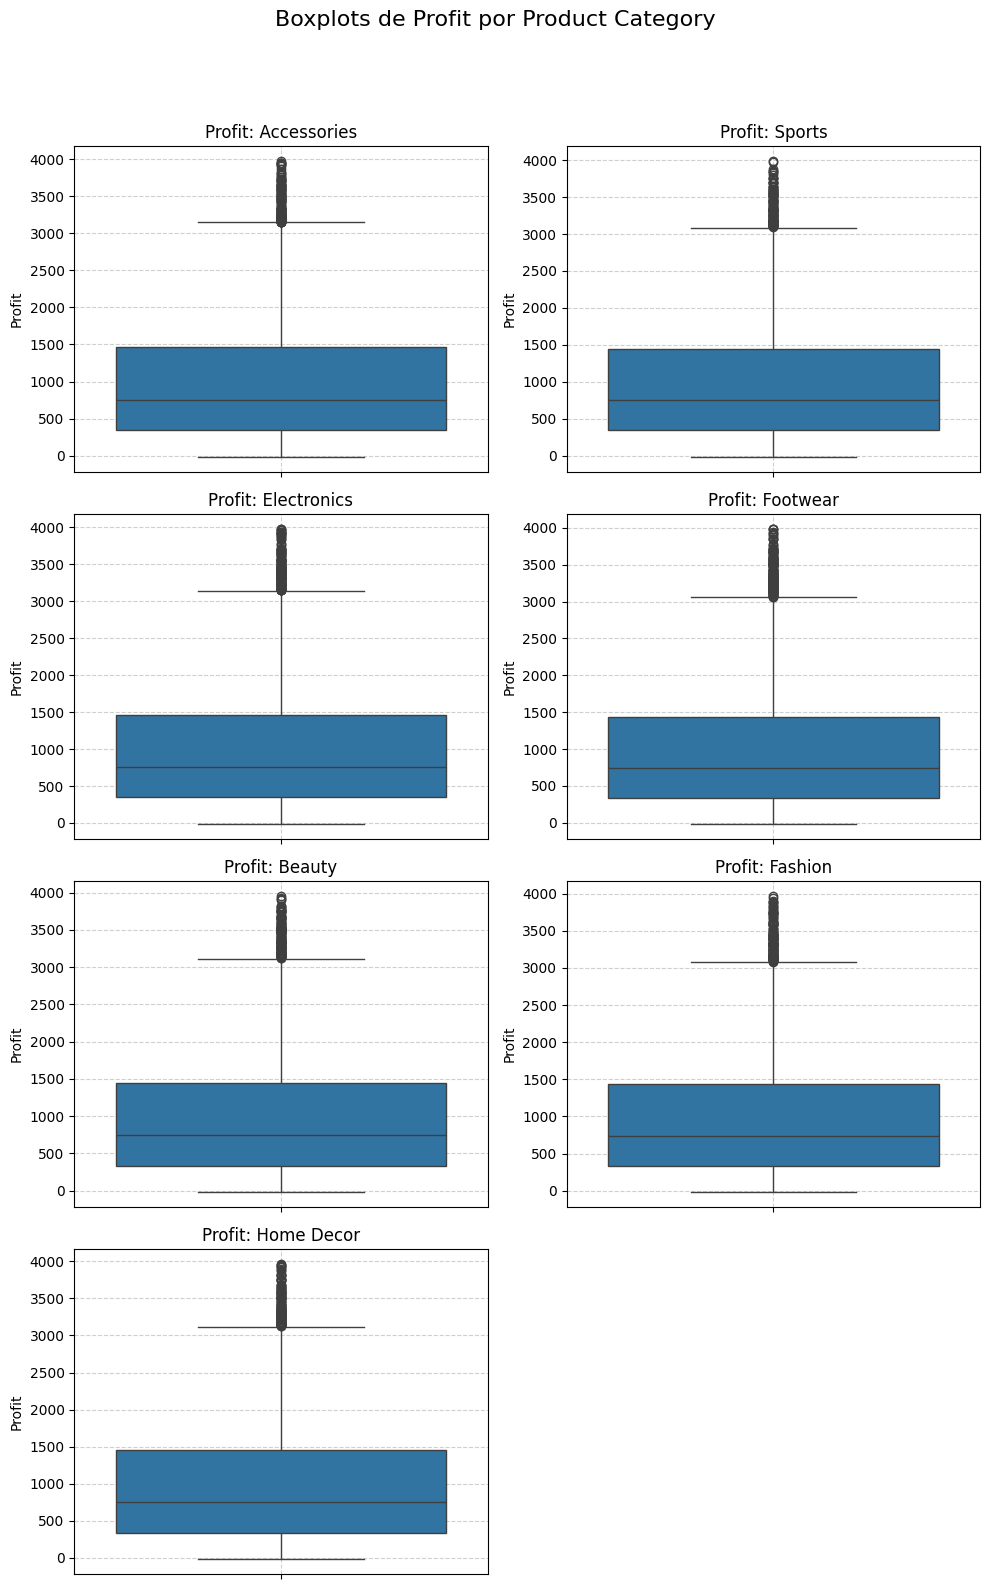

In [46]:
columna_categorica = 'product_category'
columna_numerica = 'profit'

unique_categories = data[columna_categorica].unique()
num_categories = len(unique_categories)

# Determine grid size for subplots
num_cols = 2 # You can adjust this number
num_rows = (num_categories + num_cols - 1) // num_cols
# num_rows = (7 + 3 -1) // 3 = (9) // 3  = 3

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
axes = axes.flatten()

for i, category in enumerate(unique_categories):
    subset_data = data[data[columna_categorica] == category]
    sns.boxplot(data=subset_data, y=columna_numerica, ax=axes[i])
    axes[i].set_title(f'Profit: {category}')
    axes[i].set_ylabel('Profit')
    axes[i].set_xlabel('')
    axes[i].grid(True, linestyle='--', alpha=0.6)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Boxplots de {columna_numerica.replace("_", " ").title()} por {columna_categorica.replace("_", " ").title()}', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()